# Training Quadruped Locomotion in Ant-v5 moving
- Name: John Song
- Course: EE5329
- Term: Spring2026

## 1.0 Task definition

#### 1.1 Environment : Ant-v5  (https://gymnasium.farama.org/environments/mujoco/ant/)
- The ant is a 3D quadruped robot consisting of a torso (free rotational body) with four legs attached to it, where each leg has two body parts.
- 4 legs and 1 body (8 joints)

#### 1.2 Goals    
- To coordinate the four legs to move in the forward (right) direction by applying torque to the eight hinges connecting the two body parts of each leg and the torso.

#### 1.3 Observation
- A 27-dimentional continuous vector containing the torso's 3D position and oreitantion, alongside the angles and celocities of its 8 leg joints `Observation space: Box(-inf, inf, (105,), float64)`. 

#### 1.4 Action  
- An 8-dimensional continuous vector with value between [-1,1], representing the precise motor torque applied to each of the 8 hinge joints `Action space shape: (8,)`.
- `Action Input Sample: [-0.7540165   0.88591754 -0.78097594  0.38984188 -0.946787   -0.08350106
 -0.8810074  -0.62489676]`


#### 1.5 Reward (https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/mujoco/ant_v5.py)

$$\text{Reward} = \text{healthy\_reward} + \text{forward\_reward} - \text{ctrl\_cost} - \text{contact\_cost}$$


1. *Healthy Reward*:
   - Initial Setup:  
     ```python
     healthy_reward: float = 1.0
     healthy_z_range: tuple[float, float] = (0.2, 1.0)
     ```
   - Condition:  
     If the Ant is within the healthy Z-range, it is considered healthy. The reward is applied only if `self.is_healthy` is `True`.
   - Calculation:  
     ```python
     self.is_healthy * self._healthy_reward
     ```

2. *Forward Reward*:
   - Initial Setup:  
     ```python
     forward_reward_weight: float = 1.0
     ```
   - Calculation:  
     The forward reward is based on the Ant's velocity in the x-direction (`x_velocity`), weighted by `forward_reward_weight`.
     ```python
     forward_reward = x_velocity * self._forward_reward_weight
     ```

3. *Control Cost*:
   - Initial Setup:  
     ```python
     ctrl_cost_weight: float = 0.5
     ```
   - Calculation:  
     The control cost penalizes large actions. It's computed as the sum of the squared actions, scaled by `ctrl_cost_weight`.
     ```python
     ctrl_cost = self._ctrl_cost_weight * np.sum(np.square(action))
     ```

4. *Contact Cost*:
   - Initial Setup:  
     ```python
     contact_cost_weight: float = 5e-4
     contact_force_range: tuple[float, float] = (-1.0, 1.0)
     ```
   - Calculation:  
     The contact cost penalizes the agent for excessive external contact forces. These forces are clipped within `contact_force_range` before being squared and summed. The resulting value is then scaled by `contact_cost_weight`.
     ```python
     contact_cost = self._contact_cost_weight * np.sum(np.square(self.contact_forces))
     ```

#### 1.6 Episode End 
- Terminated early if the Ant crashes ($Z_{height}$ < $0.2$). Truncated successfully if the agent survives the maximun limit $< 1,000$ timesteps

#### Why this task is interesting: 
At its core, this project presents a 3D environment where the task is to move a simulated agent (the Ant) forward, with the reward structure closely tied to both contact forces and velocity. The dynamics of balancing movement while minimizing external forces (e.g., contact with the ground) mirror real-world challenges in robotics, particularly in the context of legged locomotion.


Environment: Ant-v5
Observation space: Box(-inf, inf, (105,), float64)
Action space: Box(-1.0, 1.0, (8,), float32)
Action space shape: (8,)
Action space bounds: [[-1. -1. -1. -1. -1. -1. -1. -1.], [1. 1. 1. 1. 1. 1. 1. 1.]]
----------------------------------------------------------------------------------------------
Action Input Sample: [ 0.90117055 -0.67786455  0.81068516 -0.54777783  0.7476903   0.4576642
  0.01856261 -0.5715715 ]
----------------------------------------------------------------------------------------------
Image for Ant-v5:


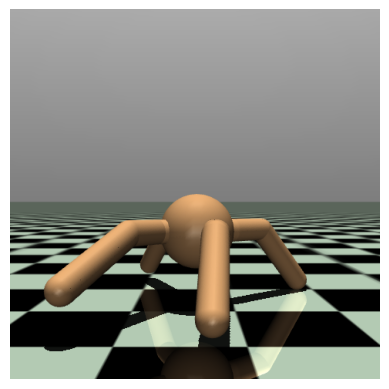

In [18]:
question1_show()

In [32]:
question1_input()

Example for Observeration, Reward, Information: 
Observation Box:
[ 7.71878893e-01  9.99785497e-01  1.18403020e-03  9.59128238e-04
  2.06552092e-02 -9.81528728e-02  4.31328392e-01 -7.61576874e-02
 -4.17756555e-01 -5.96495315e-02 -4.27962523e-01 -4.16617350e-02
  3.97836648e-01 -9.08552251e-02  1.49373666e-02  2.00060901e-01
  1.57039130e-01  1.24223063e-01  1.60625924e+00 -3.89616343e+00
  9.82446555e+00 -3.02122970e+00 -8.95417459e+00 -2.36512247e+00
 -9.61706453e+00 -1.65162289e+00  7.60575514e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.0000

## 2.0 Baseline Setup

### 2.1 Algorighm
- PPO (Proximal Policy Optimization)
- A2C (Advantage Actor-Critic)
- DDPG (Deep Deterministic Policy Gradient)
- SAC (Soft Actor-Critic)

### 2.2 hyperparameters


#### 2.2.1 PPO
```python

    model_ppo = PPO(
        "MlpPolicy",
        env_ppo,
        verbose=0,
        tensorboard_log=LOG_DIR + f"{experiment}/",
        learning_rate=0.0003, ## 0.0015/ 0.003
        n_steps=2048,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        clip_range_vf=None,
        ent_coef=0.0,
        vf_coef=0.5,
        max_grad_norm=0.5,
        use_sde=False,
        sde_sample_freq=-1,
        seed = seed,
        device="cpu"
    )

```


#### 2.2.2 A2C  

```python 
    model_a2c = A2C(
        "MlpPolicy",
        env_a2c,
        verbose=0,
        tensorboard_log=LOG_DIR + f"{experiment}/",
        learning_rate=0.0003,
        n_steps=256, ## 256*4 = 1024
        gamma=0.99,
        gae_lambda=0.95,
        ent_coef=0.0,
        vf_coef=0.5,
        max_grad_norm=0.5,
        use_rms_prop=True,
        rms_prop_eps=1e-05,
        use_sde=False,
        sde_sample_freq=-1,
        normalize_advantage=False,
        seed = seed,
        device="cpu"
    )


```

#### 2.2.3 DDPG 

```python 
    model_ddpg = DDPG(
        "MlpPolicy",
        env_ddpg,
        action_noise=action_noise,
        verbose=0,
        tensorboard_log=LOG_DIR + f"{experiment}/",
        learning_rate=0.0003,
        buffer_size=300_000, ## 50000
        learning_starts=100,
        batch_size=256,
        tau=0.005,
        gamma=0.99,
        train_freq=1,
        gradient_steps=2, ## upadate 2 among 4 envs. 
        seed = seed,
        device="auto"
    )


```

#### 2.2.4 SAC  

```python

    model_sac = SAC(
        "MlpPolicy",
        env_sac,
        verbose=0,
        tensorboard_log=LOG_DIR + f"{experiment}/",
        learning_rate=0.0003,
        buffer_size=300_000, ## 50000
        learning_starts=100,
        batch_size=256,
        tau=0.005,
        gamma=0.99,
        train_freq=1,
        gradient_steps=2,# 1
        ent_coef="auto",
        target_update_interval=1,
        target_entropy="auto",
        use_sde=False,
        sde_sample_freq=-1,
        use_sde_at_warmup=False,
        seed = seed,
        device="auto"
    )



```

### 2.3 Software

In [33]:
print(f"Python version: {sys.version}")
print(f"Gymnasium verison: {gymnasium.__version__}")
print(f"Stable-Baselines3: {sb3.__version__}")
print(f"Torch version: {torch.__version__}")

Python version: 3.11.15 (main, Mar 11 2026, 17:20:07) [GCC 14.3.0]
Gymnasium verison: 1.2.3
Stable-Baselines3: 2.8.0
Torch version: 2.11.0+cu130


### 2.4 Random Seed 
- Environment seed = 42 (trained parallel with 4 environments [42,43,44,45])
- Algorithm seed = 42 

### 2.5 File structure  
----


**Code:**
- `train.py` learning algorithms
- `evaluation.py` numeric table and recording_videos 

**Experiments File**  

- `models` trained models
- `logs` training log for learning curve, loss...
- `videos` recorded videos for 1 episode


**Utility Files**  

- `report_final.ipynb` **final report**
- `requirements.txt` | `setup-env.sh` environment setup
- `ReadMe.md` quick setup and overview of the project



## 3. Experiment

### 3.1 Experiment A (baseline_Preliminary study):
- Comparing Random Agent with **PPO** Agent baseline
- Base on PPO, change `total timesteps`
- PPO Agent is running with $1000,000$ vs. $4000,000$ timesteps, which $1000$ vs. $4000$ epsoides
- seed is random generate by system

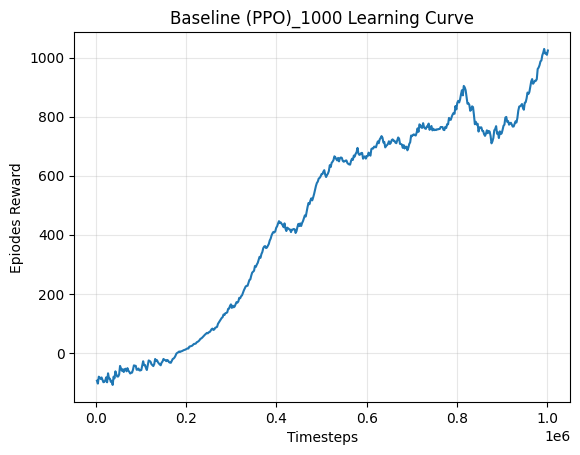

In [39]:
experiment_A_1()

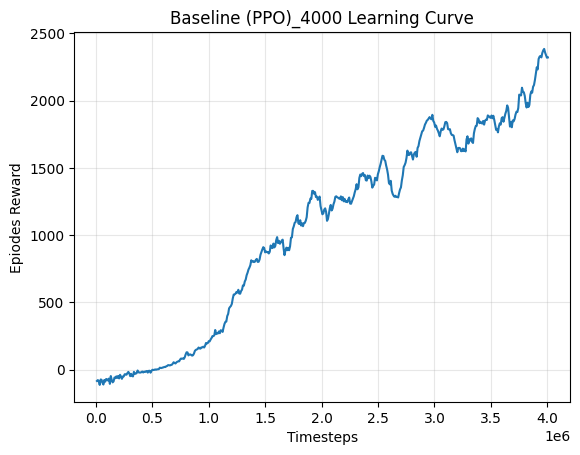

In [41]:
experiment_A_2()

### 3.2 Experiment B (one change):  
- Base on PPO, change `learning rate` within $1000,000$
- `learning rate = 0.0003`
- `learning rate = 0.0015`
- `learning rate = 0.003`

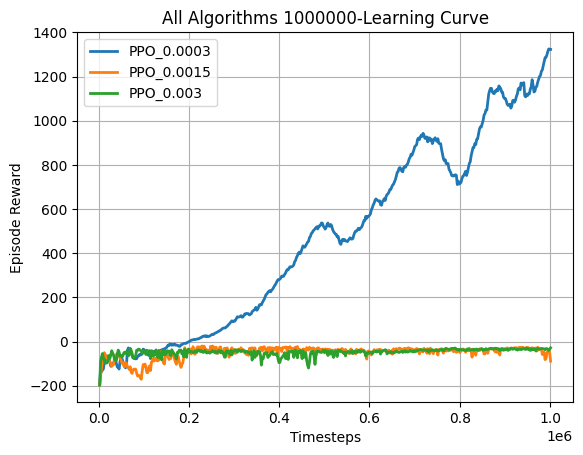

In [43]:
experiment_B()

### 3.3 Experiment C: 
- Within `total_steps = 500,000` and `total_steps = 1000,000`, benchmark in PPO, A2C, DDPG, SAC (with default hyperparameters)
- seed = 42

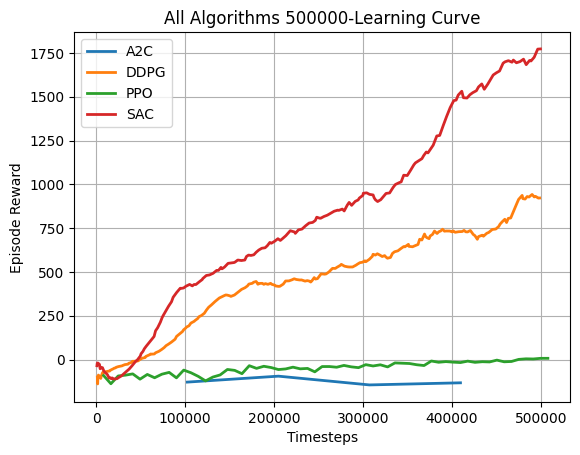

In [45]:
experiment_C_1()

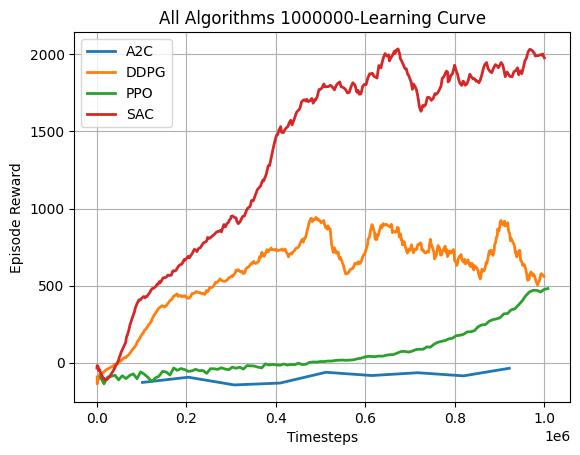

In [48]:
experiment_C_2()

**What changed between experiments:**
- Learning rate
- total_steps
- different algorithms
- different hyperparameters

## 4. Results

### 4.0 Evaluation Metrics  
1. Mean ± confidence interval episode return over 50 episodes : *shows how good it on average, how certain it is*.</br> Equation: $ci = \bar{x} ± 1.96 * \frac{s}{\sqrt{n}}$ 
3. Median and Interquartile Range (IQR) over 50 episodes: *how stable/consistent it is*


### 4.1 Baseline Result (Experiment A)

- timesteps = 1000,000 vs.4000,000


In [52]:
evaluation_A()

Experiment A: Loading trained models...

Evaluating PPO-1000 ....

Evaluating PPO-4000 ....

TRAINING SUMMARY
Environment: Ant-v5
Training timesteps: 1000_000 vs. 4000_000
Algorithms trained: PPO-1000, PPO-4000

Final Performance Over 50 episodes:
Algorithm    | Mean ± 95% CI      |     Median |        IQR |            Min / Max
--------------------------------------------------------------------------------
PPO-1000     |  1608.47 ± 156.73  |    1906.55 |     796.07 |        11.9 / 2086.6
PPO-4000     |  2992.35 ±  82.28  |    3074.34 |     125.91 |      1524.9 / 3220.0

All models have been trained and evaluated successfully!


### 4.2 Different Learning Rate (Experiment B)

In [7]:
evaluation_B()

Experiment B: Loading trained models...

Evaluating PPO (3e-4) ....

Evaluating PPO (1.5e-3) ....

Evaluating PPO (3e-3) ....

TRAINING SUMMARY
Environment: Ant-v5
Training timesteps: 1000_000
Algorithms trained: PPO (3e-4), PPO (1.5e-3), PPO (3e-3)

Final Performance Over 50 episodes:
Algorithm    | Mean ± 95% CI      |     Median |        IQR |            Min / Max
--------------------------------------------------------------------------------
PPO (3e-4)   |  2140.25 ± 266.74  |    2667.72 |    1154.09 |        25.9 / 2969.3
PPO (1.5e-3) |   -77.83 ±  89.64  |     -25.75 |      11.25 |      -2313.8 / -12.0
PPO (3e-3)   |   -26.43 ±   2.06  |     -24.57 |       8.13 |        -55.5 / -17.4

All models have been trained and evaluated successfully!


### 4.3 Benchmark Results (Experiment C)

#### 4.3.1 Timesteps = 500_000  

In [8]:
evaluation_C_1()

Experiment C: Loading trained models...

Evaluating A2C_500 ....

Evaluating DDPG_500 ....

Evaluating PPO_500 ....

Evaluating SAC_500 ....

TRAINING SUMMARY
Environment: Ant-v5
Training timesteps: 500_000
Algorithms trained: A2C_500, DDPG_500, PPO_500, SAC_500

Final Performance Over 50 episodes:
Algorithm    | Mean ± 95% CI      |     Median |        IQR |            Min / Max
--------------------------------------------------------------------------------
A2C_500      |   561.77 ±  99.88  |     563.16 |     697.88 |        -6.3 / 1013.5
DDPG_500     |   549.22 ± 141.09  |     393.28 |     654.75 |         9.8 / 2090.5
PPO_500      |   211.94 ±  73.69  |      91.56 |     168.88 |         10.9 / 867.6
SAC_500      |  2395.42 ± 136.72  |    2563.84 |     133.53 |        17.8 / 2725.4

All models have been trained and evaluated successfully!


#### 4.3.2 Timesteps = 1000_000 


In [9]:
evaluation_C_2()

Experiment C: Loading trained models...

Evaluating A2C_1000 ....

Evaluating DDPG_1000 ....

Evaluating PPO_1000 ....

Evaluating SAC_1000 ....

TRAINING SUMMARY
Environment: Ant-v5
Training timesteps: 1000_000
Algorithms trained: A2C_1000, DDPG_1000, PPO_1000, SAC_1000

Final Performance Over 50 episodes:
Algorithm    | Mean ± 95% CI      |     Median |        IQR |            Min / Max
--------------------------------------------------------------------------------
A2C_1000     |     4.21 ±   4.16  |       3.86 |      15.66 |         -40.3 / 47.3
DDPG_1000    |   872.16 ± 220.18  |     642.76 |    1278.98 |      -406.9 / 3076.9
PPO_1000     |  1523.37 ±  85.54  |    1616.55 |      79.76 |       191.8 / 1721.5
SAC_1000     |  2157.36 ± 261.06  |    2589.75 |    1582.14 |       310.6 / 3275.1

All models have been trained and evaluated successfully!


## 5. Analysis

### 5.1 What Worked: 
- Experiment A (Timestep Scaling): PPO utilizing default hyperparameters demonstrated reliable scaling. As training timesteps increased from 1,000,000 to 4,000,000, the algorithm's performance significantly improved, ultimately achieving a highly stable mean reward of `3010.34 ± 94.43`. This confirms PPO's capacity for consistent.

- Experiment C (Algorithmic Benchmarking): The comparison between on-policy (PPO, A2C) and off-policy (SAC, DDPG) algorithms revealed a strict tradeoff between sample efficiency and stability. At 500,000 timesteps, SAC (off-policy) drastically outperformed the others due to the sample efficiency provided by its replay buffer. However, SAC exhibited high variance (a large Interquartile Range).

### 5.2 What did not work:
- Experiment B (**Hyperparameter Sensitivity**): PPO proved to be highly sensitive to learning rate adjustments. While the baseline rate (3e-4) yielded successful locomotion, increasing the rate (1.5e-3 and 3e-3) resulted in total policy collapse. Higher learning rates caused destructive gradient updates that overwhelmed PPO's clipped objective function, resulting in negative rewards where the agent failed to balance.

- **Single-Environment Instability and Correlation:** During early trials of Experiment C, attempting to train A2C and DDPG using a single, non-vectorized environment resulted in a complete failure to learn. A single environment generates highly correlated, sequential data, which destabilizes neural network updates. While utilizing 4 parallel environments naturally decorrelated the data, the single-environment setup could only be salvaged by significantly increasing the size of the replay buffer. A larger buffer allowed the algorithms to store a wider variety of past experiences, effectively breaking the correlation in the sampled mini-batches and restoring the ability to learn.
  
- **Environment Logging Issue:** Integrating TensorBoard with PPO across multiple vectorized environments introduced severe logging discrepancies. Because parallel environments step asynchronously and reset at different intervals, the default TensorBoard loggers failed to accurately aggregate the mean episode rewards in real-time. Consequently, the real-time training curves for PPO were rendered unreliable.

### 5.3 Why you think the results look this way:

- Time Equals Survival (Exp A): PPO scales reliably because the environment heavily rewards staying upright. More timesteps simply equal more gradient updates, allowing the Ant to perfect its balance and max out the 1,000-step survival bonus.

- Policy Collapse (Exp B): High learning rates trigger massive mathematical updates that instantly shatter the neural network's weights, breaking the brain before it can even try to walk.

- Exp C - 500k: SAC dominates at 500,000 steps because of sample efficiency. Its off-policy replay buffer allows it to recycle past mistakes and successes, giving it a massive head start.

- Exp C - 1M : By 1,000,000 steps, A2C/DDPG choke on the Ant's 27-dimensional complexity and flatline. PPO overtakes them because its clipped objective function acts as a safety net, guaranteeing slow but stable progress.


### 5.4 Any reward-design, observation-design or hyperparameter lessons:

- No Reward-design just use original rewards-function
- Observation-design: did not add any light or sensor
- Hyperparameter
```
- Learning Rate: In PPO, the learning rate is strictly tied to the "trust region." Pushing it too high (1.5e-3) does not merely slow down learning; it causes catastrophic gradient steps that permanently shatter the neural network's weights.


-Replay Buffers: For off-policy algorithms (SAC, DDPG), a massive replay buffer is not just about having "more memory." It is mathematically required to decorrelate past experiences, ensuring that sampled mini-batches represent a diverse distribution of states rather than a single, highly correlated trajectory.

-Vectorized Environments: Running multiple parallel environments is not just a trick for faster wall-clock time. By forcing the agent to experience multiple, diverse physical states simultaneously, it drastically reduces the variance of the gradient updates, resulting in a much more stable and robust policy.

```

## 6. Coding Appendix (helper functions)

In [10]:
import gymnasium as gym
import matplotlib.pyplot as plt
import sys
import gymnasium
import torch 
import stable_baselines3 as sb3
import numpy as np
from tensorboard.backend.event_processing import event_accumulator
import os
from stable_baselines3 import A2C, DDPG, PPO, SAC


In [31]:
def question1_show():
    env_name = "Ant-v5"
    env = gym.make(env_name, render_mode="rgb_array")
    
    print(f"Environment: {env_name}")
    print(f"Observation space: {env.observation_space}")
    print(f"Action space: {env.action_space}")
    print(f"Action space shape: {env.action_space.shape}")
    print(f"Action space bounds: [{env.action_space.low}, {env.action_space.high}]")
    print(f"----------------------------------------------------------------------------------------------")
    action = env.action_space.sample()
    print(f"Action Input Sample: {action}")
    print(f"----------------------------------------------------------------------------------------------")
    print("Image for Ant-v5:")
    obs, _ = env.reset()
    for _ in range(10):
        obs, *_ = env.step(env.action_space.sample())
    frame = env.render()
    plt.imshow(frame)
    plt.axis("off")
    env.close()


def question1_input():
    env_name = "Ant-v5"
    env = gym.make(env_name, render_mode="rgb_array")
    print("Example for Observeration, Reward, Information: ")
    base = env.unwrapped
    result = base.step(env.action_space.sample())
    print(f"Observation Box:\n{result[0]}\nReward_Info:\n{result[4]}")
    env.close()


In [40]:
def learning_curve(log_dir, title):
    ea = event_accumulator.EventAccumulator(log_dir)
    ea.Reload()
    scalars = ea.Scalars("rollout/ep_rew_mean")
    steps=[s.step for s in scalars]
    values = [s.value for s in scalars]
    plt.plot(steps,values)
    plt.title(f"{title} Learning Curve")
    plt.xlabel("Timesteps")
    plt.ylabel("Epiodes Reward")
    plt.grid(True, alpha=0.3)
    plt.show()

def experiment_A_1():
    log_dir = "./logs/experiment-A/Baseline_1000/"
    title = "Baseline (PPO)_1000"
    learning_curve(log_dir, title)
def experiment_A_2():
    log_dir = "./logs/experiment-A/Baseline_4000/"
    title = "Baseline (PPO)_4000"
    learning_curve(log_dir, title)

In [47]:
def learning_curve_all_model(logs,total):

    for name, log in logs.items():
        ea = event_accumulator.EventAccumulator(log)
        ea.Reload()
        scalars = ea.Scalars("rollout/ep_rew_mean")
        steps = np.array([s.step for s in scalars])
        values = np.array([s.value for s in scalars])
        plt.plot(steps,values, label=name, linewidth=2)
    plt.title(f"All Algorithms {total}-Learning Curve")
    plt.xlabel("Timesteps")
    plt.ylabel("Episode Reward")
    plt.legend()
    plt.grid(True)
    plt.show()

def experiment_B():
    logs ={
    "PPO_0.0003": "./logs/experiment-B/PPO_0.0003/",
    "PPO_0.0015": "./logs/experiment-B/PPO_0.0015/",
    "PPO_0.003": "./logs/experiment-B/PPO_0.003/",
}
    learning_curve_all_model(logs,1000_000)

def experiment_C_1():
    logs ={
    "A2C": "./logs/experiment-C/A2C_500/",
    "DDPG": "./logs/experiment-C/DDPG_500/",
    "PPO": "./logs/experiment-C/PPO_500/",
    "SAC": "./logs/experiment-C/SAC_500/"
}
    learning_curve_all_model(logs,500_000)

def experiment_C_2():
    logs ={
    "A2C": "./logs/experiment-C/A2C_1000/",
    "DDPG": "./logs/experiment-C/DDPG_1000/",
    "PPO": "./logs/experiment-C/PPO_1000/",
    "SAC": "./logs/experiment-C/SAC_1000/"
}
    learning_curve_all_model(logs,1000_000)

In [50]:
def evaluate_all_models(algorithms, models, env_name="Ant-v5", n_eval_episodes=50):
    evaluation_env = gym.make(env_name)
    results = {}

    for alg, model in zip(algorithms, models):
        print(f"\nEvaluating {alg} ....")
        
        rewards = []
        for _ in range(n_eval_episodes):
            obs, _ = evaluation_env.reset()
            done = False 
            total_reward = 0

            while not done: 
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, _ = evaluation_env.step(action)
                total_reward += reward
                done = terminated or truncated 

            rewards.append(total_reward)

        # Statistical Calculations
        data = np.array(rewards)
        mean_reward = data.mean()
        std_reward = data.std(ddof=1)
        
        # 95% Confidence Interval
        ci = 1.96 * std_reward / np.sqrt(len(data))
        
        # IQR Calculation
        q1 = np.percentile(data, 25)
        q3 = np.percentile(data, 75)

        # Store all metrics in the results dictionary
        results[alg] = {
            'mean': data.mean(),
            'ci': ci,
            'median': np.median(data),
            'q1': q1,
            'q3': q3,
            'iqr': q3 - q1,
            'min': data.min(),
            'max': data.max()}
    evaluation_env.close()
    return results
    
def printout(eval_results, algorithms, timesteps):
    print("\n" + "=" * 60)
    print("TRAINING SUMMARY")
    print("=" * 60)
    print(f"Environment: Ant-v5")
    print(f"Training timesteps: {timesteps}")
    print(f"Algorithms trained: {', '.join(algorithms)}")
    print("\nFinal Performance Over 50 episodes:")

    print(f"{'Algorithm':<12} | {'Mean ± 95% CI':<18} | {'Median':>10} | {'IQR':>10} | {'Min / Max':>20}")
    print("-" * 80)
    for alg in algorithms:
        res = eval_results[alg]
        stats = f"{res['mean']:>8.2f} ± {res['ci']:>6.2f}"
        range_str = f"{res['min']:.1f} / {res['max']:.1f}"
        
        print(f"{alg:<12} | {stats:<18} | {res['median']:>10.2f} | {res['iqr']:>10.2f} | {range_str:>20}")

    print("\nAll models have been trained and evaluated successfully!")

In [51]:
def evaluation_A():
    algorithms = ['PPO-1000', 'PPO-4000']
    models = []
    timesteps = "1000_000 vs. 4000_000"
    print("Experiment A: Loading trained models...")
    
            # Load PPO model
    model_ppo_loaded = PPO.load("./models/experiment-A_ppo_ant_1000000_42")
    models.append(model_ppo_loaded)
    
    model_ppo_loaded = PPO.load("./models/experiment-A_ppo_ant_4000000_42")
    models.append(model_ppo_loaded)
    eval_results = evaluate_all_models(algorithms, models)
    printout(eval_results, algorithms,timesteps)

def evaluation_B():
    algorithms = ['PPO (3e-4)', 'PPO (1.5e-3)', 'PPO (3e-3)']
    models = []
    timesteps = "1000_000"
    print("Experiment B: Loading trained models...")
    
                    # Load PPO model
    model_ppo_loaded = PPO.load("./models/experiment-B_ppo_ant_0.0003_42")
    models.append(model_ppo_loaded)
    
    model_ppo_loaded = PPO.load("./models/experiment-B_ppo_ant_0.0015_42")
    models.append(model_ppo_loaded)
    
    model_ppo_loaded = PPO.load("./models/experiment-B_ppo_ant_0.003_42")
    models.append(model_ppo_loaded)
    
    eval_results = evaluate_all_models(algorithms, models)
    
    printout(eval_results, algorithms,timesteps)

def evaluation_C_1():
    algorithms = ['A2C_500', 'DDPG_500', 'PPO_500', 'SAC_500']
    models = []
    timesteps = "500_000"
    print("Experiment C: Loading trained models...")
    model_a2c_loaded = A2C.load("./models/experiment-C_a2c_ant_500000_42")
    models.append(model_a2c_loaded)
    
            # Load DDPG model
    model_ddpg_loaded = DDPG.load("./models/experiment-C_ddpg_ant_500000_42")
    models.append(model_ddpg_loaded)
    
            # Load PPO model
    model_ppo_loaded = PPO.load("./models/experiment-C_ppo_ant_500000_42")
    models.append(model_ppo_loaded)
    
    
            # Load SAC model
    model_sac_loaded = SAC.load("./models/experiment-C_sac_ant_500000_42")
    models.append(model_sac_loaded)
    
    eval_results = evaluate_all_models(algorithms, models)
    printout(eval_results, algorithms,timesteps)

def evaluation_C_2():
    algorithms = ['A2C_1000', 'DDPG_1000', 'PPO_1000', 'SAC_1000']
    models = []
    timesteps = "1000_000"
    print("Experiment C: Loading trained models...")
    model_a2c_loaded = A2C.load("./models/experiment-C_a2c_ant_1000000_42")
    models.append(model_a2c_loaded)
    
            # Load DDPG model
    model_ddpg_loaded = DDPG.load("./models/experiment-C_ddpg_ant_1000000_42")
    models.append(model_ddpg_loaded)
    
            # Load PPO model
    model_ppo_loaded = PPO.load("./models/experiment-C_ppo_ant_1000000_42")
    models.append(model_ppo_loaded)
    
    
            # Load SAC model
    model_sac_loaded = SAC.load("./models/experiment-C_sac_ant_1000000_42")
    models.append(model_sac_loaded)
    
    eval_results = evaluate_all_models(algorithms, models)
    printout(eval_results, algorithms,timesteps)

## 7.References
- https://gymnasium.farama.org/environments/mujoco/ant/
- https://stable-baselines3.readthedocs.io/en/master/guide/install.html
- https://colab.research.google.com/github/NeuromatchAcademy/course-content-dl/blob/main/projects/ReinforcementLearning/robolympics.ipynb
